In [1]:
# Sales & Demand Forecasting for Businesses
# Future Interns - Machine Learning Task 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the Superstore sales dataset

file_path = "../data/Sample - Superstore.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully.
Shape of dataset: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Basic dataset information

print("Columns in dataset:")
print(df.columns)

print("\nDataset info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Columns in dataset:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          

In [4]:
# Convert Order Date into proper datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

# Check if conversion worked
print("Missing Order Dates after conversion:", df["Order Date"].isnull().sum())

# Sort data by date
df = df.sort_values("Order Date")

df[["Order Date", "Sales"]].head()

Missing Order Dates after conversion: 0


,Order Date,Sales
7980,2014-01-03,16.448
739,2014-01-04,11.784
740,2014-01-04,272.736
741,2014-01-04,3.540
1759,2014-01-05,19.536


In [5]:
# Create monthly sales dataset

monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()

monthly_sales.columns = ["Date", "Sales"]

print("Monthly sales data created successfully.")
print(monthly_sales.head())
print(monthly_sales.tail())

Monthly sales data created successfully.
        Date      Sales
0 2014-01-31  14236.895
1 2014-02-28   4519.892
2 2014-03-31  55691.009
3 2014-04-30  28295.345
4 2014-05-31  23648.287
         Date        Sales
43 2017-08-31   63120.8880
44 2017-09-30   87866.6520
45 2017-10-31   77776.9232
46 2017-11-30  118447.8250
47 2017-12-31   83829.3188


C:\Users\zenit\AppData\Local\Temp\ipykernel_28576\2632195007.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()


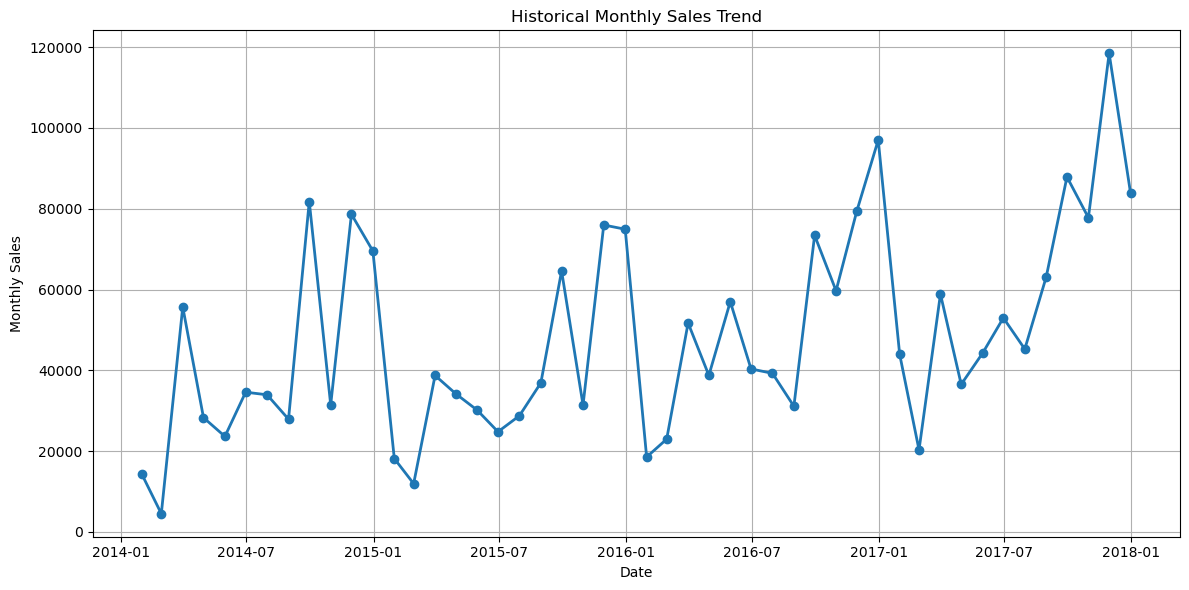

In [6]:
# Plot historical monthly sales

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["Date"], monthly_sales["Sales"], marker="o", linewidth=2)

plt.title("Historical Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.grid(True)
plt.tight_layout()

plt.show()

In [7]:
# Feature engineering for forecasting

monthly_sales["Year"] = monthly_sales["Date"].dt.year
monthly_sales["Month"] = monthly_sales["Date"].dt.month
monthly_sales["Quarter"] = monthly_sales["Date"].dt.quarter

# Trend feature: 1, 2, 3, ... over time
monthly_sales["Time_Index"] = np.arange(1, len(monthly_sales) + 1)

monthly_sales.head()

,Date,Sales,Year,Month,Quarter,Time_Index
0,2014-01-31,14236.895,2014,1,1,1
1,2014-02-28,4519.892,2014,2,1,2
2,2014-03-31,55691.009,2014,3,1,3
3,2014-04-30,28295.345,2014,4,2,4
4,2014-05-31,23648.287,2014,5,2,5


In [8]:
# Split data into training and testing sets

features = ["Year", "Month", "Quarter", "Time_Index"]
target = "Sales"

X = monthly_sales[features]
y = monthly_sales[target]

# Use last 12 months as test data
X_train = X.iloc[:-12]
X_test = X.iloc[-12:]

y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

print("Training months:", len(X_train))
print("Testing months:", len(X_test))

Training months: 36
Testing months: 12


In [9]:
# Train Linear Regression forecasting model

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [10]:
# Predict sales for test period

y_pred = model.predict(X_test)

test_results = monthly_sales.iloc[-12:].copy()
test_results["Predicted_Sales"] = y_pred

test_results[["Date", "Sales", "Predicted_Sales"]]

,Date,Sales,Predicted_Sales
36,2017-01-31,43971.3740,20250.475238
37,2017-02-28,20301.1334,34017.299046
38,2017-03-31,58872.3528,47784.122854
39,2017-04-30,36521.5361,33477.088926
40,2017-05-31,44261.1102,47243.912734
41,2017-06-30,52981.7257,61010.736542
42,2017-07-31,45264.4160,46703.702613
43,2017-08-31,63120.8880,60470.526422
44,2017-09-30,87866.6520,74237.350230
45,2017-10-31,77776.9232,59930.316301


In [11]:
# Evaluate model performance

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R2 Score:", round(r2, 4))

Model Evaluation Results
------------------------
Mean Absolute Error (MAE): 12211.04
Root Mean Squared Error (RMSE): 17043.04
R2 Score: 0.5627


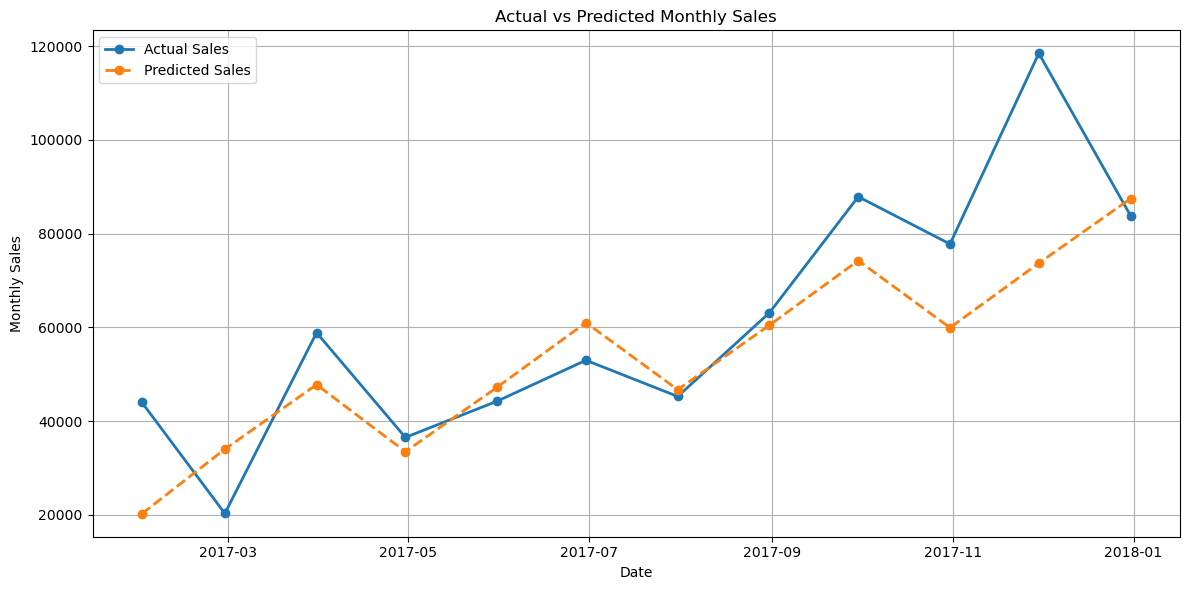

In [12]:
# Visualize actual vs predicted sales

plt.figure(figsize=(12, 6))

plt.plot(test_results["Date"], test_results["Sales"], marker="o", linewidth=2, label="Actual Sales")
plt.plot(test_results["Date"], test_results["Predicted_Sales"], marker="o", linestyle="--", linewidth=2, label="Predicted Sales")

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [13]:
# Forecast sales for the next 6 months

last_date = monthly_sales["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6,
    freq="M"
)

future_data = pd.DataFrame({
    "Date": future_dates
})

future_data["Year"] = future_data["Date"].dt.year
future_data["Month"] = future_data["Date"].dt.month
future_data["Quarter"] = future_data["Date"].dt.quarter
future_data["Time_Index"] = np.arange(
    monthly_sales["Time_Index"].max() + 1,
    monthly_sales["Time_Index"].max() + 1 + len(future_data)
)

future_predictions = model.predict(future_data[features])

future_data["Forecasted_Sales"] = future_predictions

future_data[["Date", "Forecasted_Sales"]]

C:\Users\zenit\AppData\Local\Temp\ipykernel_28576\3318590674.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


,Date,Forecasted_Sales
0,2018-01-31,25457.062734
1,2018-02-28,39223.886542
2,2018-03-31,52990.710350
3,2018-04-30,38683.676421
4,2018-05-31,52450.500230
5,2018-06-30,66217.324038


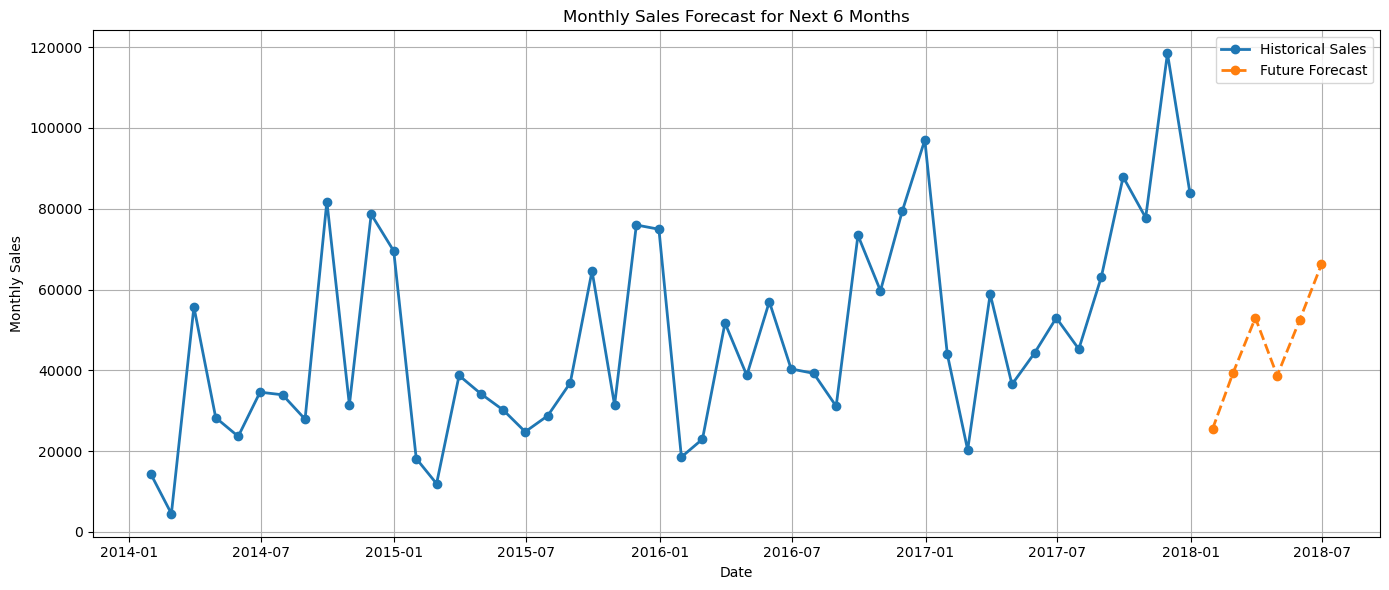

In [14]:
# Visualize historical sales and future forecast

plt.figure(figsize=(14, 6))

plt.plot(monthly_sales["Date"], monthly_sales["Sales"], marker="o", linewidth=2, label="Historical Sales")
plt.plot(future_data["Date"], future_data["Forecasted_Sales"], marker="o", linestyle="--", linewidth=2, label="Future Forecast")

plt.title("Monthly Sales Forecast for Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [15]:
# Save future forecast results to CSV

future_output = future_data[["Date", "Forecasted_Sales"]].copy()

future_output.to_csv("../outputs/future_sales_forecast.csv", index=False)

print("Forecast saved successfully to outputs/future_sales_forecast.csv")

Forecast saved successfully to outputs/future_sales_forecast.csv


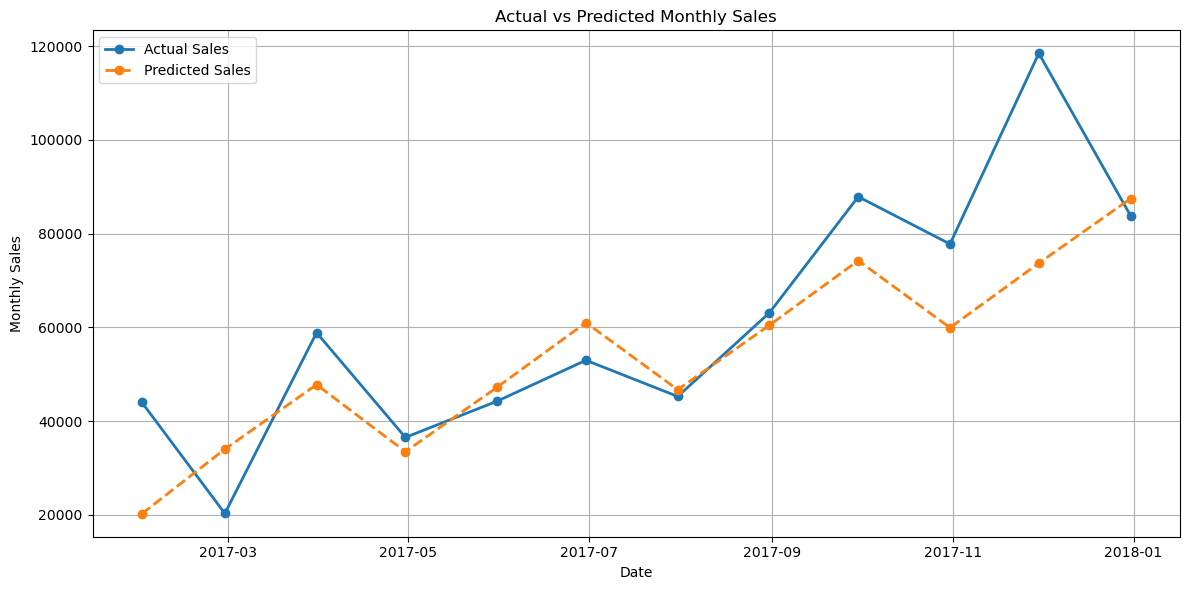

In [16]:
# Save actual vs predicted chart

plt.figure(figsize=(12, 6))

plt.plot(test_results["Date"], test_results["Sales"], marker="o", linewidth=2, label="Actual Sales")
plt.plot(test_results["Date"], test_results["Predicted_Sales"], marker="o", linestyle="--", linewidth=2, label="Predicted Sales")

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../images/actual_vs_predicted_sales.png", dpi=300)
plt.show()

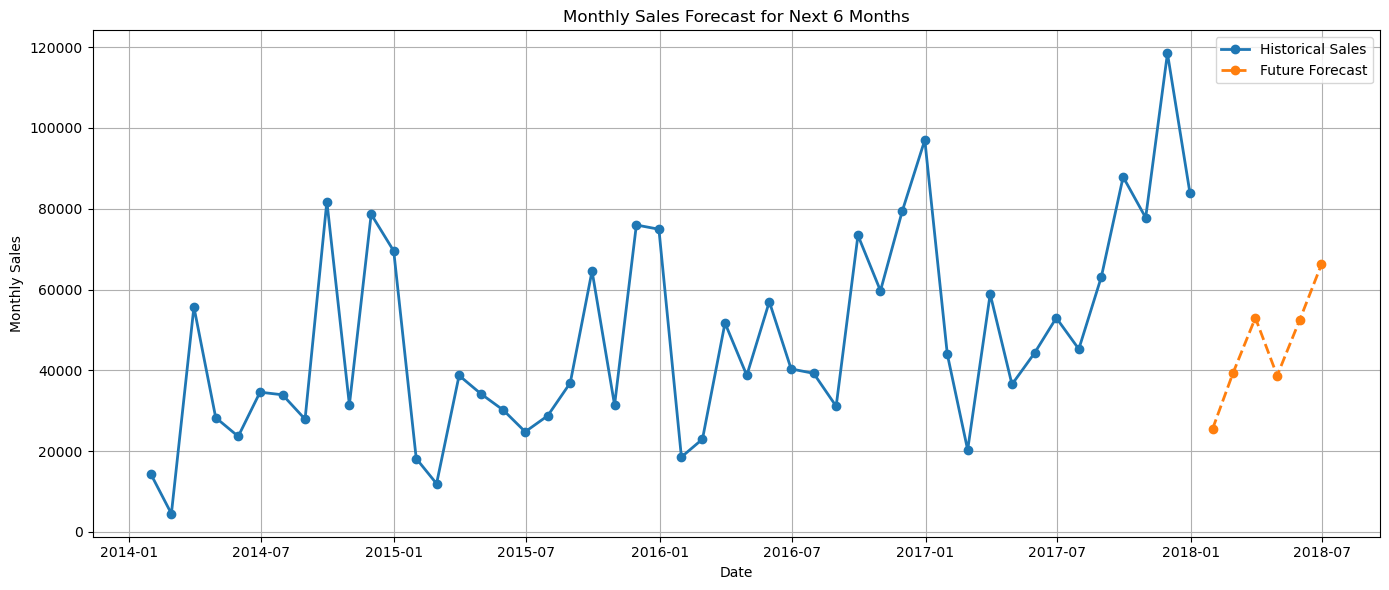

In [17]:
# Save future forecast chart

plt.figure(figsize=(14, 6))

plt.plot(monthly_sales["Date"], monthly_sales["Sales"], marker="o", linewidth=2, label="Historical Sales")
plt.plot(future_data["Date"], future_data["Forecasted_Sales"], marker="o", linestyle="--", linewidth=2, label="Future Forecast")

plt.title("Monthly Sales Forecast for Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../images/future_sales_forecast.png", dpi=300)
plt.show()

## Business Insights and Interpretation

This project forecasts monthly sales using historical Superstore sales data. The data was cleaned, converted into monthly sales totals, and enhanced with time-based features such as year, month, quarter, and time index.

A Linear Regression model was trained using earlier monthly sales data and tested on the most recent 12 months. The model achieved the following results:

- Mean Absolute Error (MAE): 12211.04
- Root Mean Squared Error (RMSE): 17043.04
- R2 Score: 0.5627

The forecast gives a business-friendly estimate of expected sales for the next 6 months. A store owner or business manager can use this forecast to plan inventory, manage cash flow, prepare staffing, and avoid overstocking or stock shortages.

The actual vs predicted sales chart shows how closely the model follows recent sales patterns. The future forecast chart provides a clear visual view of expected upcoming sales trends.